In [2]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image
from research_and_analysis.utils.model_loader import ModelLoader

In [3]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, conscerns, and motives.")

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}"

class Perspective(BaseModel):
    analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

# --- Define the state schema ---
class GenerateAnalystsState(TypedDict):
    topic: str # research topic
    max_analysts: int # number of analysts
    human_analyst_feedback: str # Analyst asking questions
    analysts: List[Analyst]


# prompt
analyst_instructions = """You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

loader = ModelLoader()
llm = loader.load_llm()

{"config_keys": ["embedding_model", "retriever", "llm"], "timestamp": "2025-10-14T09:37:21.235565Z", "level": "info", "event": "YAML config load"}
{"provider": "openai", "model": "gpt-4o", "timestamp": "2025-10-14T09:37:21.238575Z", "level": "info", "event": "Loaded LLM"}


In [4]:
def create_analyst(state: GenerateAnalystsState):
    """
    It is creating my analyst.
    Args:
        state: (_type_): _description
    """
    topic = state['topic']
    max_analysts = state['max_analysts']
    human_analyst_feedback = state.get("human_analyst_feedback", "")
    
    structured_llm = llm.with_structured_output(Perspective)

    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
    )

    analyst = structured_llm.invoke([SystemMessage(content=system_messages)] + [HumanMessage(content="Generate the set of analysts.")])

    return {"analysts": analyst.analysts}

state = GenerateAnalystsState(topic="Education", max_analysts=5, human_analyst_feedback="Keep the scope limited to AI")
create_analyst(state)


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Emily Chen', role='AI in Personalized Learning', affiliation='Institute for AI in Education', description='Dr. Chen focuses on how AI can be used to tailor educational experiences to individual student needs, enhancing engagement and learning outcomes. She is concerned with ensuring that AI systems are designed to be inclusive and equitable, providing personalized learning opportunities for all students.'),
  Analyst(name='Professor Raj Patel', role='AI in Educational Accessibility', affiliation='Global Education Accessibility Initiative', description='Professor Patel is dedicated to exploring how AI can improve accessibility in education for students with disabilities. His work involves developing AI tools that assist in creating more inclusive learning environments, ensuring that educational content is accessible to all learners regardless of their physical or cognitive abilities.'),
  Analyst(name='Dr. Sarah Thompson', role='AI in Curriculum Developme

In [5]:
GenerateAnalystsState(
    topic="FinTech",
    max_analysts=5,
    human_analyst_feedback="give me real information"
)

{'topic': 'FinTech',
 'max_analysts': 5,
 'human_analyst_feedback': 'give me real information'}

In [6]:
def human_feedback(state):
    """
    Args:
        state: (_type_): _description
    """
    pass

In [7]:
def should_continue(state):
    """
    Args:
        state: (_type_): _description
    """
    
    human_analyst_feedback = state.get('human_analyst_feedback', None)
    
    if human_analyst_feedback and human_analyst_feedback.strip():
        return "create_analyst"
    else:
        return END
    

In [8]:
memory = MemorySaver()

In [9]:
analyst = Analyst(name="Bhagwat Chate", role="GenAI Architect", affiliation='Stanford University', description='I am expert in the field of Generative AI')

In [10]:
print(analyst.persona)

Name: Bhagwat Chate
Role: GenAI Architect
Affiliation: Stanford University
Description: I am expert in the field of Generative AI


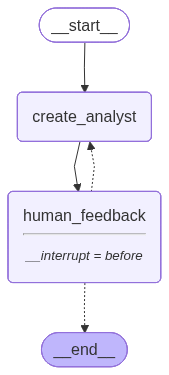

In [11]:
from typing import TypedDict

# --- Build graph ---
builder = StateGraph(GenerateAnalystsState)

# Register your nodes
builder.add_node("create_analyst", create_analyst)
builder.add_node("human_feedback", human_feedback)

# Add edges (use node names as strings)
builder.add_edge(START, "create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analyst", END])

# Compile graph
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

# Visualize
display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
thread = {'configurable': {'thread_id': 1}}
max_analysts = 4
topic = "LangGraph framework from startup perspective"

for event in graph.stream({'topic': topic, 'max_analysts': max_analysts}, thread,  stream_mode='values'):
    result = event.get('analysts', '')

    if result:
        for analyst in result:
            print(f"name: {analyst.name}")
            print(f"description: {analyst.description}")
            print(f"affiliation: {analyst.affiliation}")
            print(f"role: {analyst.role}")
            print("_"*50)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


name: Sophia Tran
description: Sophia focuses on evaluating the market potential of emerging technologies like LangGraph. Her primary concern is understanding how LangGraph can disrupt existing markets and create new opportunities for startups. She is motivated by identifying high-growth sectors and advising startups on strategic market entry.
affiliation: Tech Venture Insights
role: Market Analyst
__________________________________________________
name: Raj Patel
description: Raj is dedicated to analyzing the technical aspects of the LangGraph framework. His focus is on the framework's scalability, integration capabilities, and technical challenges. Raj is concerned with how startups can leverage LangGraph to enhance their technological stack and improve product offerings.
affiliation: Innovatech Solutions
role: Technical Analyst
__________________________________________________
name: Emily Chen
description: Emily's focus is on assessing the investment potential of startups utilizing

In [13]:
state = graph.get_state(thread)
state

StateSnapshot(values={'topic': 'LangGraph framework from startup perspective', 'max_analysts': 4, 'analysts': [Analyst(name='Sophia Tran', role='Market Analyst', affiliation='Tech Venture Insights', description='Sophia focuses on evaluating the market potential of emerging technologies like LangGraph. Her primary concern is understanding how LangGraph can disrupt existing markets and create new opportunities for startups. She is motivated by identifying high-growth sectors and advising startups on strategic market entry.'), Analyst(name='Raj Patel', role='Technical Analyst', affiliation='Innovatech Solutions', description="Raj is dedicated to analyzing the technical aspects of the LangGraph framework. His focus is on the framework's scalability, integration capabilities, and technical challenges. Raj is concerned with how startups can leverage LangGraph to enhance their technological stack and improve product offerings."), Analyst(name='Emily Chen', role='Investment Analyst', affiliati

In [14]:
state.next

('human_feedback',)

In [15]:
graph.update_state(thread, 
                   {"human_analyst_feedback": "Along with LangGraph add the LangSmith also. Also focus on latest enterprise applications"},
                   as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a8e16-e1d4-6253-8002-5cf6dc81907c'}}

In [16]:
graph.get_state(thread)

StateSnapshot(values={'topic': 'LangGraph framework from startup perspective', 'max_analysts': 4, 'human_analyst_feedback': 'Along with LangGraph add the LangSmith also. Also focus on latest enterprise applications', 'analysts': [Analyst(name='Sophia Tran', role='Market Analyst', affiliation='Tech Venture Insights', description='Sophia focuses on evaluating the market potential of emerging technologies like LangGraph. Her primary concern is understanding how LangGraph can disrupt existing markets and create new opportunities for startups. She is motivated by identifying high-growth sectors and advising startups on strategic market entry.'), Analyst(name='Raj Patel', role='Technical Analyst', affiliation='Innovatech Solutions', description="Raj is dedicated to analyzing the technical aspects of the LangGraph framework. His focus is on the framework's scalability, integration capabilities, and technical challenges. Raj is concerned with how startups can leverage LangGraph to enhance thei

### We have updated the state with human feedback. Now, let's re-run the create analysts node once again as per the flow

In [17]:
for event in graph.stream({'topic': topic, 'max_analysts': max_analysts}, thread,  stream_mode='values'):
    result = event.get('analysts', '')

    if result:
        for analyst in result:
            print(f"name: {analyst.name}")
            print(f"description: {analyst.description}")
            print(f"affiliation: {analyst.affiliation}")
            print(f"role: {analyst.role}")
            print("_"*50)

name: Sophia Tran
description: Sophia focuses on evaluating the market potential of emerging technologies like LangGraph. Her primary concern is understanding how LangGraph can disrupt existing markets and create new opportunities for startups. She is motivated by identifying high-growth sectors and advising startups on strategic market entry.
affiliation: Tech Venture Insights
role: Market Analyst
__________________________________________________
name: Raj Patel
description: Raj is dedicated to analyzing the technical aspects of the LangGraph framework. His focus is on the framework's scalability, integration capabilities, and technical challenges. Raj is concerned with how startups can leverage LangGraph to enhance their technological stack and improve product offerings.
affiliation: Innovatech Solutions
role: Technical Analyst
__________________________________________________
name: Emily Chen
description: Emily's focus is on assessing the investment potential of startups utilizing

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


name: Sophia Tran
description: Sophia focuses on how startups can leverage the LangGraph framework to enhance their technological capabilities. She is particularly interested in how LangGraph can be integrated into existing startup ecosystems to drive innovation and efficiency. Her main concern is ensuring that startups can adopt these technologies without significant disruption to their current operations.
affiliation: Tech Innovators Inc.
role: Startup Technology Strategist
__________________________________________________
name: Raj Patel
description: Raj is dedicated to exploring the latest enterprise applications of LangGraph and LangSmith. He analyzes how these frameworks can be utilized to solve complex problems in large organizations, focusing on scalability and integration with existing enterprise systems. His motive is to identify solutions that can provide a competitive edge to enterprises through advanced language processing capabilities.
affiliation: Global Enterprises Ltd

In [18]:
state = graph.get_state(thread)
state

StateSnapshot(values={'topic': 'LangGraph framework from startup perspective', 'max_analysts': 4, 'human_analyst_feedback': 'Along with LangGraph add the LangSmith also. Also focus on latest enterprise applications', 'analysts': [Analyst(name='Sophia Tran', role='Startup Technology Strategist', affiliation='Tech Innovators Inc.', description='Sophia focuses on how startups can leverage the LangGraph framework to enhance their technological capabilities. She is particularly interested in how LangGraph can be integrated into existing startup ecosystems to drive innovation and efficiency. Her main concern is ensuring that startups can adopt these technologies without significant disruption to their current operations.'), Analyst(name='Raj Patel', role='Enterprise Solutions Architect', affiliation='Global Enterprises Ltd.', description='Raj is dedicated to exploring the latest enterprise applications of LangGraph and LangSmith. He analyzes how these frameworks can be utilized to solve comp

In [19]:
state.next

('human_feedback',)

In [20]:
graph.update_state(thread,
                   {"human_analyst_feedback": None}, as_node='human_feedback')

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a8e17-10de-685d-8006-bc5c8154f51b'}}

In [21]:
state = graph.get_state(thread)
state

StateSnapshot(values={'topic': 'LangGraph framework from startup perspective', 'max_analysts': 4, 'human_analyst_feedback': None, 'analysts': [Analyst(name='Sophia Tran', role='Startup Technology Strategist', affiliation='Tech Innovators Inc.', description='Sophia focuses on how startups can leverage the LangGraph framework to enhance their technological capabilities. She is particularly interested in how LangGraph can be integrated into existing startup ecosystems to drive innovation and efficiency. Her main concern is ensuring that startups can adopt these technologies without significant disruption to their current operations.'), Analyst(name='Raj Patel', role='Enterprise Solutions Architect', affiliation='Global Enterprises Ltd.', description='Raj is dedicated to exploring the latest enterprise applications of LangGraph and LangSmith. He analyzes how these frameworks can be utilized to solve complex problems in large organizations, focusing on scalability and integration with exist

In [22]:
state.next

()

In [23]:
from langchain.document_loaders import WikipediaLoader
docs = WikipediaLoader(query='LangGraph').load()
print(docs[0].page_content[:200])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely over


# Workflow 2

In [33]:
class InterviewState(BaseModel):
    pass

In [38]:
def ask_question(state: InterviewState):
    """
    Args:
        state (InterviewState): _description_
    """
    pass

def search_web(state: InterviewState):
    """
    Args:
        state (InterviewState): _description_
    """
    pass

def search_wikipedia(state: InterviewState):
    """
    Args:
        state (InterviewState): _description_
    """
    pass

def generate_answer(state: InterviewState):
    """
    Args:
        state (InterviewState): _description_
    """
    pass

def save_interview(state: InterviewState):
    """
    Args:
        state (InterviewState): _description_
    """
    pass

def write_section(state: InterviewState):
    """
    Args:
        state (InterviewState): _description_
    """
    pass

def router_messages(state: GenerateAnalystsState):
    pass

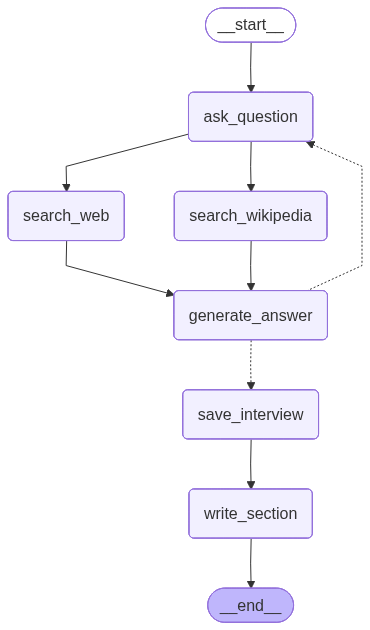

In [ ]:
interview_builder = StateGraph(InterviewState)

interview_builder.add_node('ask_question', ask_question)
interview_builder.add_node('search_web', search_web)
interview_builder.add_node('search_wikipedia', search_wikipedia)
interview_builder.add_node('generate_answer', generate_answer)
interview_builder.add_node('save_interview', save_interview)
interview_builder.add_node('write_section', write_section)

interview_builder.add_edge(START, 'ask_question')
interview_builder.add_edge('ask_question', 'search_web')
interview_builder.add_edge('ask_question', 'search_wikipedia')
interview_builder.add_edge('search_web', 'generate_answer')
interview_builder.add_edge('search_wikipedia', 'generate_answer')
interview_builder.add_conditional_edges("generate_answer", router_messages, ["ask_question", "save_interview"])

interview_builder.add_edge('save_interview', 'write_section')
interview_builder.add_edge('write_section', END)

interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name='Conduct Interview')
display(Image(interview_graph.get_graph().draw_mermaid_png()))